# 🌲 Módulo 2.4: Métodos de Ensamblado - Random Forest
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 10 horas

---

## 🎯 Objetivos del Módulo

Un solo árbol es bueno, pero un bosque es más fuerte. En este módulo, descubrirás el poder de los **métodos de ensamblado (Ensemble Methods)**, una de las técnicas más potentes en Machine Learning. Nos centraremos en el **Random Forest**, un algoritmo que soluciona la principal debilidad de los árboles de decisión: su tendencia al overfitting.

Al finalizar, serás capaz de:

- ✅ Entender la "sabiduría de la multitud" y por qué los ensamblados superan a los modelos individuales.
- ✅ Dominar la técnica de **Bagging (Bootstrap Aggregating)**, el pilar fundamental de Random Forest.
- ✅ Entrenar, evaluar y optimizar modelos de **Random Forest** para clasificación y regresión.
- ✅ Utilizar la **Importancia de Características (Feature Importance)** para interpretar qué variables son más influyentes en tu modelo Random Forest.
- ✅ Comprender el papel del parámetro `n_estimators` y cómo afecta al rendimiento.

**¡Prepárate para dejar de confiar en un solo experto y empezar a escuchar a un comité de ellos!**

---

## 📚 Tabla de Contenidos

1. [La Sabiduría de la Multitud: Métodos de Ensamblado](#1-ensamblado)
   - [¿Por qué un Ensamblado es Mejor?](#1.1-porque)
2. [Bagging: Bootstrap Aggregating](#2-bagging)
   - [Paso a Paso: Cómo Funciona el Bagging](#2.1-pasos)
3. [Random Forest: El Bosque Aleatorio](#3-random-forest)
   - [Añadiendo Aleatoriedad a Bagging](#3.1-aleatoriedad)
   - [Implementación de Random Forest para Clasificación](#3.2-implementacion-clas)
   - [Random Forest para Regresión](#3.3-implementacion-reg)
4. [Interpretación: Importancia de Características](#4-importancia)
   - [¿Qué Variables Mira más el Bosque?](#4.1-variables)
5. [Ventajas y Desventajas de Random Forest](#5-ventajas)
6. [Resumen y Próximos Pasos](#6-resumen)

---

## 👨‍👩‍👧‍👦 1. La Sabiduría de la Multitud: Métodos de Ensamblado <a id='1-ensamblado'></a>

### 1.1 ¿Por qué un Ensamblado es Mejor? <a id='1.1-porque'></a>

La idea central de los métodos de ensamblado es simple: **combinar las predicciones de varios modelos (llamados "aprendices débiles" o "weak learners") para crear un único modelo superior (un "aprendiz fuerte" o "strong learner")**.

**Analogía**: Imagina que estás en un concurso. En lugar de responder tú solo, puedes preguntar a 100 personas y quedarte con la respuesta más votada. La probabilidad de que la mayoría se equivoque es mucho menor que la probabilidad de que una sola persona se equivoque.

Un ensamblado funciona si los modelos que lo componen son:
1.  **Diversos**: Cometen errores en diferentes sitios. Si todos se equivocan en lo mismo, el ensamblado también se equivocará.
2.  **Mejores que el azar**: Cada modelo individual debe tener un rendimiento al menos ligeramente superior al de una predicción aleatoria.

Los árboles de decisión son candidatos perfectos para ser los aprendices débiles en un ensamblado, ya que son muy sensibles a los datos de entrenamiento (alta varianza), lo que facilita la creación de árboles diversos.

## 🛍️ 2. Bagging: Bootstrap Aggregating <a id='2-bagging'></a>

El **Bagging** es una de las técnicas de ensamblado más importantes y es la base del Random Forest.

### 2.1 Paso a Paso: Cómo Funciona el Bagging <a id='2.1-pasos'></a>

1.  **Bootstrap (Muestreo con Reemplazo)**: Se crean múltiples subconjuntos de datos a partir del conjunto de entrenamiento original. Cada subconjunto tiene el mismo tamaño que el original, pero se crea **muestreando con reemplazo**. Esto significa que algunas muestras pueden aparecer varias veces en un subconjunto, mientras que otras pueden no aparecer en absoluto.

2.  **Training (Entrenamiento Paralelo)**: Se entrena un modelo (un árbol de decisión, en nuestro caso) de forma independiente en cada uno de los subconjuntos de datos. Como cada árbol ve una versión ligeramente diferente de los datos, aprenderá patrones ligeramente diferentes, creando la **diversidad** que necesitamos.

3.  **Aggregating (Agregación)**: Para hacer una nueva predicción, se le pregunta a todos los árboles del ensamblado. 
    -   En **clasificación**, la predicción final es la clase más votada (**votación por mayoría**).
    -   En **regresión**, la predicción final es el **promedio** de las predicciones de todos los árboles.

![Bagging](imagenes/Bagging.png)

## 🌲 3. Random Forest: El Bosque Aleatorio <a id='3-random-forest'></a>

### 3.1 Añadiendo Aleatoriedad a Bagging <a id='3.1-aleatoriedad'></a>

Un Random Forest es, en esencia, un modelo de Bagging de árboles de decisión con un toque extra de aleatoriedad para aumentar la diversidad de los árboles.

**¿Cuál es el truco?**

Cuando un árbol del bosque está decidiendo en qué característica y umbral dividir un nodo, **no considera todas las características disponibles**. En su lugar, selecciona un **subconjunto aleatorio de características** y solo busca la mejor división entre ellas.

**¿Por qué hacer esto?**

Imagina que tienes una característica muy predictiva. En un modelo de Bagging normal, la mayoría de los árboles empezarían dividiendo por esa característica, lo que haría que todos los árboles fueran muy similares (correlacionados). Al forzar a cada árbol a considerar solo un subconjunto aleatorio de características, nos aseguramos de que los árboles sean más diferentes entre sí, lo que **reduce la varianza** y hace que el modelo final sea más robusto.

### 3.2 Implementación de Random Forest para Clasificación <a id='3.2-implementacion-clas'></a>

Vamos a usar el dataset de `make_moons` para ver cómo un Random Forest puede superar a un único árbol de decisión.

In [1]:
from sklearn.datasets import make_moons # Generar un conjunto de datos de "lunas"
from sklearn.model_selection import train_test_split # Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.ensemble import RandomForestClassifier # Importar el clasificador Random Forest
from sklearn.tree import DecisionTreeClassifier # Importar el clasificador Árbol de Decisión
from sklearn.metrics import accuracy_score # Medir la precisión del modelo
import matplotlib.pyplot as plt # Para visualización
import numpy as np # Para operaciones numéricas

# Generar datos de "lunas" para clasificación, esto crea un conjunto de datos no linealmente separable
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entrenar un único Árbol de Decisión 
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(f"Accuracy de un solo Árbol de Decisión: {accuracy_score(y_test, y_pred_tree):.4f}")

# Entrenar un Random Forest
# n_estimators es el número de árboles en el bosque, n_estimators=100 es un valor comúnmente usado 
# y nos dice que usemos 100 árboles, cada uno entrenado con una muestra aleatoria del conjunto de datos
# n_jobs=-1 indica que se usen todos los núcleos del procesador para acelerar el entrenamiento
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 usa todos los cores
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print(f"Accuracy de Random Forest (100 árboles): {accuracy_score(y_test, y_pred_rf):.4f}")

Accuracy de un solo Árbol de Decisión: 0.8560
Accuracy de Random Forest (100 árboles): 0.8960


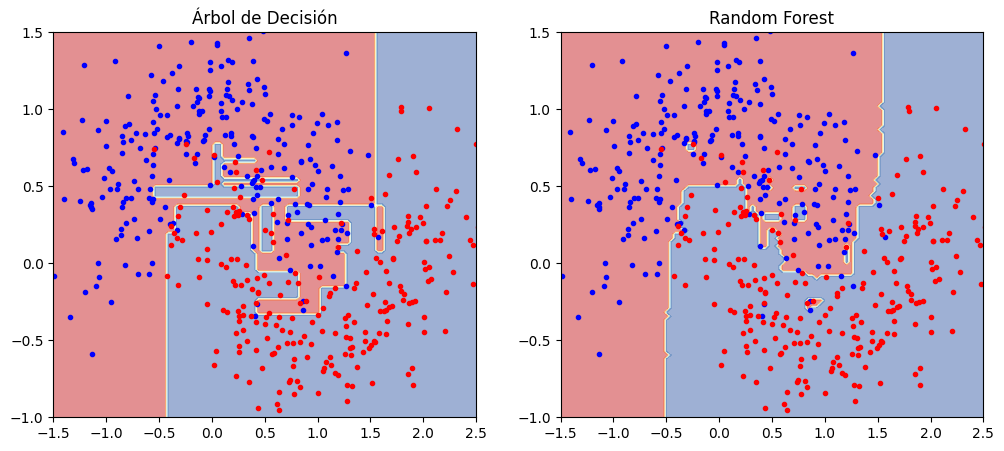

In [2]:
# Función para visualizar los límites de decisión
# Aqui vamos a crear una malla de puntos en el espacio de características 
# y predecir la clase para cada punto
# Luego, usamos estos puntos para dibujar los límites de decisión del clasificador
# Esto nos ayuda a ver cómo el modelo clasifica diferentes regiones del espacio 
# de características
def plot_decision_boundary(clf, X, y, axes, title):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.RdYlBu, alpha=0.5)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r.")
    plt.title(title)
    plt.axis(axes)

fig, axes_fig = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(axes_fig[0])
plot_decision_boundary(tree_clf, X, y, [-1.5, 2.5, -1, 1.5], "Árbol de Decisión")
plt.sca(axes_fig[1])
plot_decision_boundary(rf_clf, X, y, [-1.5, 2.5, -1, 1.5], "Random Forest")
plt.show()

**Observaciones:**
- El límite de decisión del único árbol es irregular y claramente sobreajustado a los datos de entrenamiento (alta varianza).
- El límite de decisión del Random Forest es mucho más suave y general. Al promediar las predicciones de muchos árboles, se reduce el ruido y se obtiene un modelo más robusto.

### 3.3 Random Forest para Regresión <a id='3.3-implementacion-reg'></a>

El concepto es exactamente el mismo para regresión. Se entrenan múltiples árboles de regresión en subconjuntos de datos, y la predicción final es el **promedio** de las predicciones de todos los árboles.

RMSE del Random Forest Regressor: 0.4220


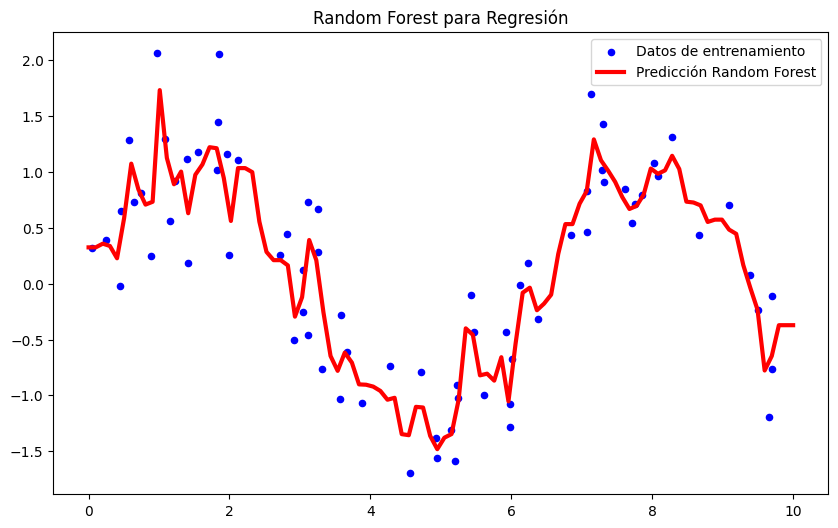

In [3]:
from sklearn.ensemble import RandomForestRegressor # Importar el regresor Random Forest
from sklearn.metrics import mean_squared_error # Medir el error cuadrático medio

# Datos de ejemplo para regresión
# Generar datos sintéticos para regresión
# Aquí usamos una función seno con algo de ruido
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 10
y_reg = np.sin(X_reg).ravel() + np.random.randn(100) * 0.5

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, random_state=42)

# Entrenar un Random Forest Regressor
# n_estimators es el número de árboles en el bosque
# n_jobs=-1 usa todos los cores para acelerar el entrenamiento
# Si n_jobs no se especifica, el valor por defecto es 1, 
# lo que significa que solo se usa un núcleo del procesador
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

# Predecir y evaluar el modelo
y_pred_reg = rf_reg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
print(f"RMSE del Random Forest Regressor: {rmse:.4f}")

# Visualización
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_plot = rf_reg.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_r, y_train_r, c='b', s=20, label='Datos de entrenamiento')
plt.plot(X_plot, y_plot, c='r', lw=3, label='Predicción Random Forest')
plt.title('Random Forest para Regresión')
plt.legend()
plt.show()

---

## 📊 4. Interpretación: Importancia de Características <a id='4-importancia'></a>

### 4.1 ¿Qué Variables Mira más el Bosque? <a id='4.1-variables'></a>

Aunque un Random Forest es más una "caja negra" que un solo árbol, nos ofrece una herramienta muy útil para la interpretación: la **importancia de características (feature importance)**.

**¿Cómo se calcula?**

Para cada característica, se mide cuánto ha contribuido en promedio a **reducir la impureza** en todos los árboles del bosque. Una característica que se usa a menudo en las divisiones de los nodos superiores (cerca de la raíz) y que produce grandes ganancias de información tendrá una alta importancia.

Esto es extremadamente útil para entender qué variables son las más predictivas en nuestro problema.

Importancia de las Características (Dataset Iris):


,Característica,Importancia
2,petal length (cm),0.436130
3,petal width (cm),0.436065
0,sepal length (cm),0.106128
1,sepal width (cm),0.021678


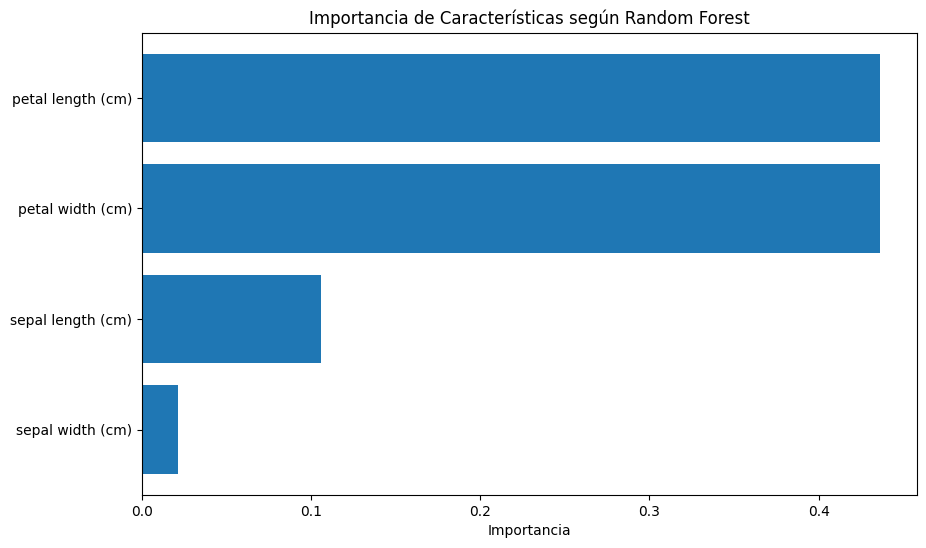

In [4]:
from sklearn.datasets import load_iris # Cargar el dataset Iris
import pandas as pd

# Usar el dataset Iris, que tiene características con nombres
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Entrenar un Random Forest en el dataset Iris
rf_iris = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_iris.fit(X_iris, y_iris)

# Obtener la importancia de las características
# La importancia de las características indica qué tan útiles son las características 
# individuales para hacer predicciones
importances = rf_iris.feature_importances_

# Crear un DataFrame para visualizarlo mejor
feature_importance_df = pd.DataFrame({
    'Característica': iris.feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

print("Importancia de las Características (Dataset Iris):")
display(feature_importance_df)

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Característica'], feature_importance_df['Importancia'])
plt.xlabel('Importancia')
plt.title('Importancia de Características según Random Forest')
plt.gca().invert_yaxis()
plt.show()

Claramente, las características relacionadas con los pétalos (`petal width` y `petal length`) son mucho más importantes para clasificar las flores Iris que las relacionadas con los sépalos.

---

## ✅ 5. Ventajas y Desventajas de Random Forest <a id='5-ventajas'></a>

### Ventajas
1.  **Alto Rendimiento**: Es uno de los mejores algoritmos "listos para usar". Generalmente ofrece un rendimiento muy bueno con poca optimización de hiperparámetros.
2.  **Robusto al Overfitting**: La combinación de Bagging y la selección aleatoria de características lo hace mucho menos propenso al overfitting que un solo árbol.
3.  **No Requiere Escalado de Datos**: Al igual que los árboles individuales, no es sensible a la escala de las características.
4.  **Maneja Datos Faltantes**: Puede manejar valores nulos de forma robusta.
5.  **Proporciona Importancia de Características**: Permite interpretar qué variables son más predictivas.

### Desventajas
1.  **Menos Interpretable**: Es una "caja negra". No podemos visualizar un bosque de 500 árboles como lo haríamos con uno solo.
2.  **Más Lento**: Entrenar y predecir con cientos de árboles es más costoso computacionalmente que con un solo modelo.
3.  **Puede no ser la mejor opción para datos muy esparsos** (muchos ceros), como los datos de texto.

---

## 📝 6. Resumen y Próximos Pasos <a id='6-resumen'></a>

### 🎉 ¡Has construido tu primer bosque! Has dominado uno de los algoritmos más potentes y versátiles del Machine Learning.

#### ✅ Lo que has aprendido:

1. **El Poder del Ensamblado**
   - Que combinar muchos modelos débiles y diversos crea un modelo fuerte y robusto.
   - La técnica de **Bagging**, que entrena modelos en subconjuntos de datos muestreados con reemplazo.

2. **Random Forest**
   - Que un Random Forest es un ensamblado de árboles de decisión que añade una capa extra de aleatoriedad al seleccionar características.
   - Cómo esta doble aleatoriedad combate eficazmente el overfitting.
   - A implementar `RandomForestClassifier` y `RandomForestRegressor` en Scikit-learn.

3. **Interpretabilidad**
   - A extraer y visualizar la **importancia de las características** para entender qué variables son las más predictivas, abriendo una pequeña ventana en la "caja negra".

---

### 🚀 Próximo Módulo: Boosting - El Otro Gran Ensamblado

El Bagging (y Random Forest) construye los árboles en paralelo, de forma independiente. Pero, ¿y si los construyéramos en secuencia, donde cada nuevo árbol intenta corregir los errores del anterior?

Esa es la idea detrás del **Boosting**, la otra gran familia de métodos de ensamblado. En el próximo módulo, explorarás:

- **AdaBoost** y **Gradient Boosting**: Los algoritmos fundamentales de boosting.
- **XGBoost** y **LightGBM**: Las implementaciones modernas y ultra optimizadas que dominan las competiciones de Machine Learning (como Kaggle).

**Has aprendido a construir un bosque donde cada árbol crece por su cuenta. Ahora, ¡vamos a enseñar a los árboles a aprender de los errores de sus predecesores!**